In [1]:
from __future__ import annotations

import operator
from typing import TypedDict, List, Annotated

from pydantic import BaseModel, Field
from langgraph.graph import StateGraph, START, END
from langgraph.types import Send
import os
from langchain_groq import ChatGroq
from langchain_core.messages import SystemMessage, HumanMessage
from dotenv import load_dotenv

load_dotenv()

True

In [82]:
GROQ_API_KEY = os.getenv("GROQ_API_KEY")
if not GROQ_API_KEY:
    raise ValueError("GROQ_API_KEY is missing. Please add it to your .env file.")

In [83]:
class Task(BaseModel):
    id: int
    title: str
    brief: str = Field(..., description="What to cover")

In [84]:
class Plan(BaseModel):
    blog_title: str
    tasks: List[Task]

In [85]:
class State(TypedDict):
    topic: str
    plan: Plan
    # reducer: results from workers get concatenated automatically
    sections: Annotated[List[str], operator.add]
    final: str

In [86]:
llm = ChatGroq(
    model="openai/gpt-oss-120b",
    api_key=GROQ_API_KEY
)

In [87]:
#core function that decides the overall plan and create a list of tasks.
def orchestrator(state: State) -> dict:

    plan = llm.with_structured_output(Plan).invoke(
        [
            SystemMessage(
                content=(
                    "Create a blog plan with 5-7 sections on the following topic."
                )
            ),
            HumanMessage(content=f"Topic: {state['topic']}"),
        ]
    )
    return {"plan": plan}

In [88]:
#worker function that takes a task and generates a section of the blog.
def fanout(state: State):
    return [Send("worker", {"task": task, "topic": state["topic"], "plan": state["plan"]})
            for task in state["plan"].tasks]

In [89]:
def worker(payload: dict) -> dict:

    # payload contains what we sent
    task = payload["task"]
    topic = payload["topic"]
    plan = payload["plan"]

    blog_title = plan.blog_title

    section_md = llm.invoke(
        [
            SystemMessage(content="Write one clean Markdown section."),
            HumanMessage(
                content=(
                    f"Blog: {blog_title}\n"
                    f"Topic: {topic}\n\n"
                    f"Section: {task.title}\n"
                    f"Brief: {task.brief}\n\n"
                    "Return only the section content in Markdown."
                )
            ),
        ]
    ).content.strip()

    return {"sections": [section_md]}

In [90]:
#combines all the sections into a final blog post and saves it to a file.
import re
from pathlib import Path

def reducer(state: State) -> dict:
    # 1. Extract the title from the Pydantic 'Plan' object safely
    title = state["plan"].blog_title
    
    # 2. Extract and merge the markdown sections
    body = "\n\n".join(state["sections"]).strip()
    final_md = f"# {title}\n\n{body}\n"
    
    # 3. SANITIZE THE FILENAME: Remove colons, slashes, and special characters
    clean_title = title.lower().replace(" ", "_")
    clean_title = re.sub(r'[:/\\?*|<>]', '', clean_title) # Strips OS-forbidden characters
    
    # 4. Save to file
    filename = f"{clean_title}.md"
    output_path = Path(filename)
    output_path.write_text(final_md, encoding="utf-8")
    
    print(f"Successfully saved file to: {output_path.absolute()}")
    return {"final": final_md}


In [91]:
g = StateGraph(State)
g.add_node("orchestrator", orchestrator)
g.add_node("worker", worker)
g.add_node("reducer", reducer)

g.add_edge(START, "orchestrator")
g.add_conditional_edges("orchestrator", fanout, ["worker"])
g.add_edge("worker", "reducer")
g.add_edge("reducer", END)

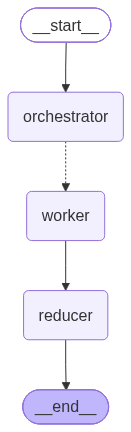

In [92]:
app = g.compile()

app

In [93]:
out = app.invoke({"topic": "Write a blog on Self Attention", "sections": []})

Successfully saved file to: c:\Users\Admin\Desktop\AgentPress  Multi Agent Blog Writing Platform\AgentPress-Multi-Agent-Blog-Writing-Platform-with-LangGraph\notebooks\understanding_self-attention_the_core_of_modern_deep_learning.md


In [94]:
out

{'topic': 'Write a blog on Self Attention',
 'plan': Plan(blog_title='Understanding Self-Attention: The Core of Modern Deep Learning', tasks=[Task(id=1, title='Introduction to Attention Mechanisms', brief='Explain the motivation behind attention in neural networks, historical context, and why self-attention matters.'), Task(id=2, title='Mathematical Foundations of Self-Attention', brief='Derive the query-key-value formulation, scaling factor, and softmax operation with clear equations.'), Task(id=3, title='Self-Attention in Practice: The Transformer Architecture', brief='Show how self-attention is integrated into the Transformer, including multi‑head attention and positional encoding.'), Task(id=4, title='Implementation Walkthrough (Python & PyTorch)', brief='Provide a step‑by‑step code example building a self‑attention layer from scratch and testing it on a toy sequence.'), Task(id=5, title='Benefits and Limitations', brief='Discuss the advantages (parallelism, long‑range dependencies